# **Licenciatura em Ciências da Computação**

### Aprendizagem Computacional 25/26

Árvores, SVM, Gradient Boosting, Hyperparameter Search, Bias/Variance, Confusion Matrix, ROC/PR-AUC, Threshold Tuning

It follows a **clean supervised learning workflow**:

1. Split data into **train** and **test**
2. Use the **training set only** for model comparison and hyperparameter search
3. Choose the best model using cross-validation
4. Choose the classification **threshold using out-of-fold predictions on the training set**
5. Fit the final model on the full training set
6. Evaluate **once** on the untouched test set

Main topics:
- Decision Trees
- SVM
- Gradient Boosting
- Bias / Variance
- Hyperparameter Search
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve
- Threshold Tuning

## Imports

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
)
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/josepedro/.cache/kagglehub/datasets/alexteboul/diabetes-health-indicators-dataset/versions/1


## Utility functions
A couple of small helper functions.

In [42]:
def plot_confusion_matrix_simple(cm, labels=("Negative", "Positive")):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=35)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


def summarize_grid(grid, model_name):
    row = {
        "model": model_name,
        "best_params": grid.best_params_,
        "best_cv_accuracy": round(grid.best_score_, 4),
    }
    return row

def drop_na_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Drop rows that contain any NaNs (simple baseline)."""
    return df.dropna(axis=0).reset_index(drop=True)

# 1) Real dataset

We will use the **Breast Cancer Wisconsin** dataset from scikit-learn.

This is a binary classification problem, which is perfect for:
- confusion matrix
- ROC curve
- PR curve
- threshold tuning

In [43]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)
print("Class distribution:")
print(y.value_counts().sort_index())
print(data.target_names)
X.head()

Dataset shape: (569, 30)
Class distribution:
target
0    212
1    357
Name: count, dtype: int64
['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


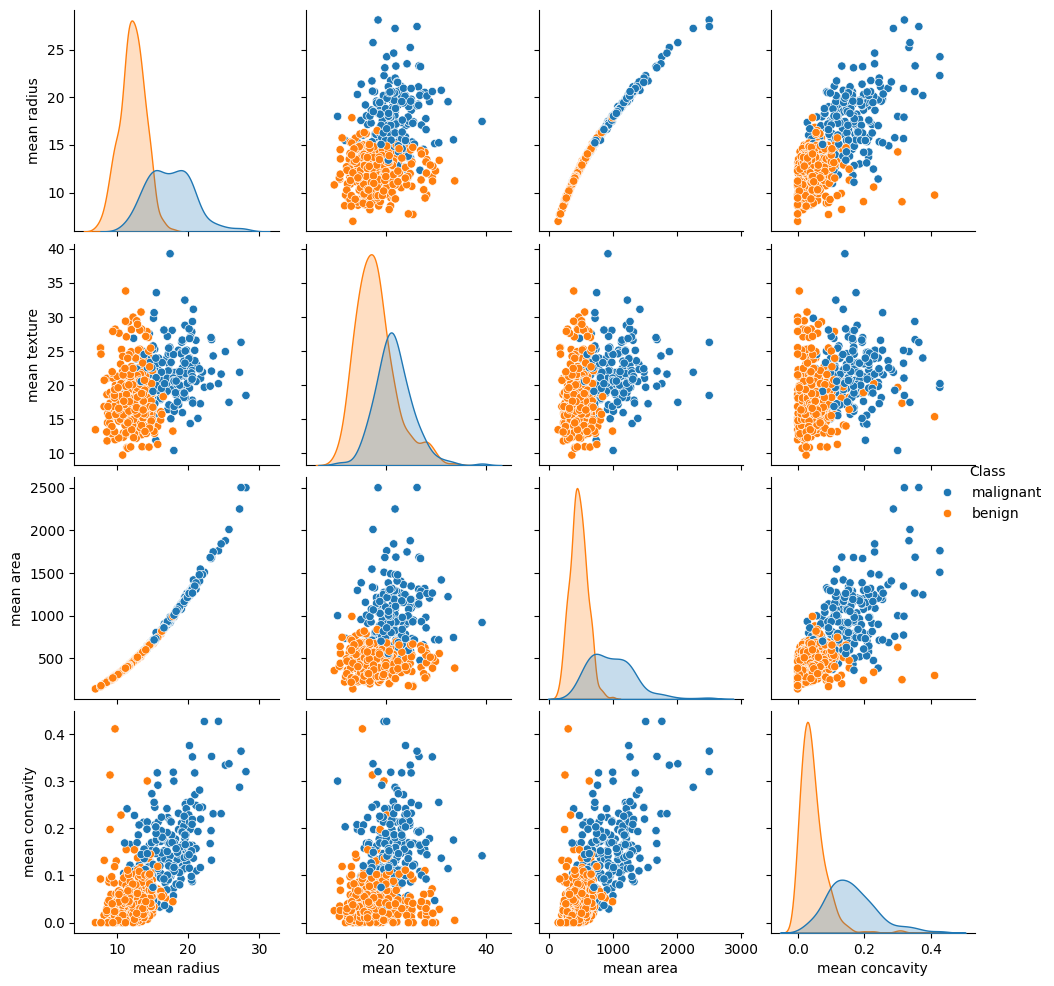

In [44]:
df = X.copy()
df["target"] = y

g = sns.pairplot(
    df,
    vars=["mean radius", "mean texture", "mean area", "mean concavity"],
    hue="target"
)

g._legend.set_title("Class")
g._legend.texts[0].set_text("malignant")
g._legend.texts[1].set_text("benign")
plt.show()

## Train / test split

The test set will stay untouched until the very end.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape: (455, 30)
Test shape:  (114, 30)


# 2) Bias / Variance intuition with Decision Trees


A shallow tree may **underfit**.  
A very deep tree may **overfit**.

We will vary `max_depth` and compare:
- training accuracy
- cross-validation accuracy

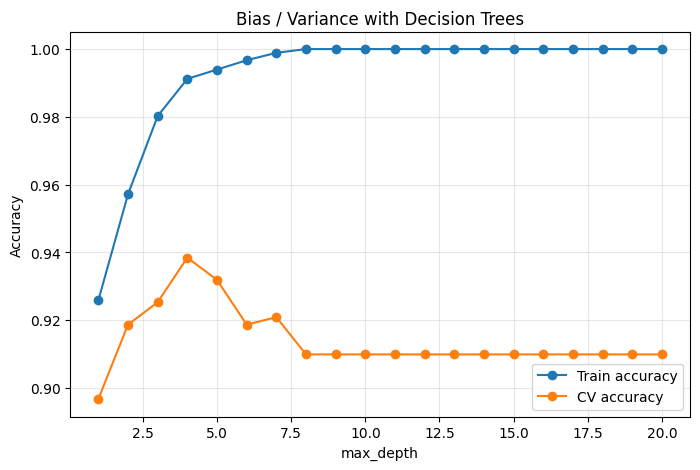

In [46]:
depths = range(1, 21)

train_scores = []
cv_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)

    scores = cross_validate(
        tree,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        return_train_score=True,
        n_jobs=-1
    )

    train_scores.append(scores["train_score"].mean())
    cv_scores.append(scores["test_score"].mean())

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker="o", label="Train accuracy")
plt.plot(depths, cv_scores, marker="o", label="CV accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Bias / Variance with Decision Trees")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretation

Typical pattern when increasing model complexity (e.g., tree depth):

*   **Low depth**: both training and CV scores are low → the model is too simple and cannot capture the underlying pattern (underfitting / high bias).

*   **Moderate depth**: both scores improve → the model becomes expressive enough to learn useful structure in the data.

*   **Very high depth**: training score continues to increase while the CV score stops improving or starts decreasing → the model begins to memorize the training data (overfitting / high variance).

This behaviour illustrates the bias–variance tradeoff:

*   High bias models are too simple and underfit the data.

*   High variance models are too complex and overfit the training data.

The goal is to find a balance where the model is complex enough to capture the signal but still generalizes well to unseen data.



# 3) SVM intuition with a toy dataset

On real datasets, SVM decision boundaries are hard to visualize.

So we first use a simple 2D dataset to build intuition for:
- `C`
- `gamma`
- smooth vs wiggly decision boundaries

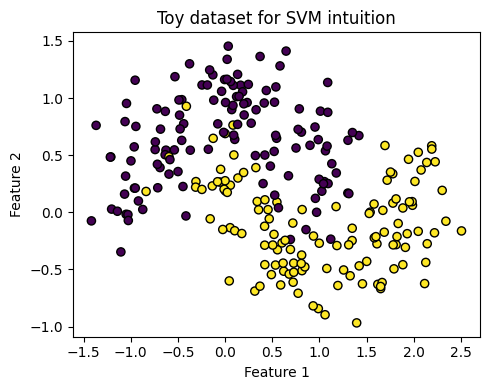

In [47]:
X_toy, y_toy = make_moons(n_samples=250, noise=0.25, random_state=42)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy, edgecolor="k", s=35)
ax.set_title("Toy dataset for SVM intuition")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.tight_layout()
plt.show()

## Visual effect of `C` and `gamma`

Useful intuition:
- `C` controls how strict the model is with training errors
- `gamma` controls how local and flexible the boundary becomes

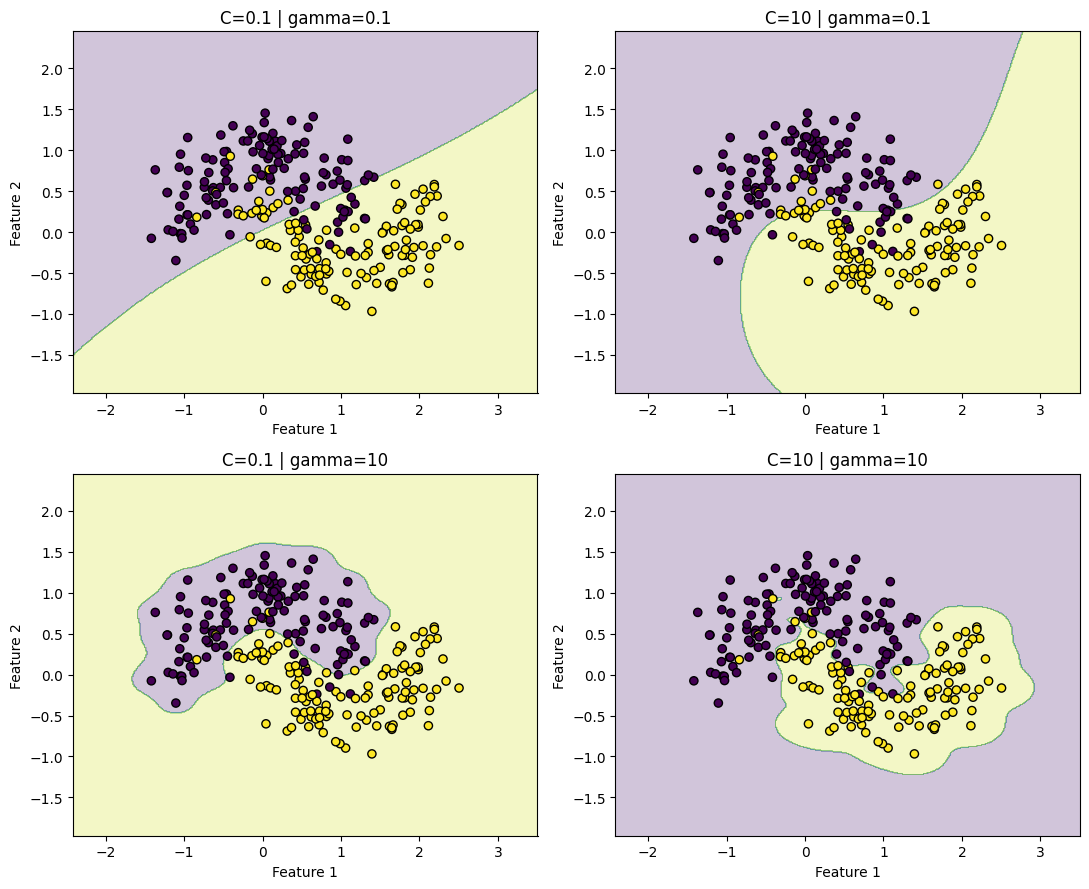

In [48]:
svm_configs = [
    {"C": 0.1, "gamma": 0.1},
    {"C": 10,  "gamma": 0.1},
    {"C": 0.1, "gamma": 10},
    {"C": 10,  "gamma": 10},
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.ravel()

for ax, cfg in zip(axes, svm_configs):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=cfg["C"], gamma=cfg["gamma"]))  #RBF -> polynomial kernel → non-linear boundary
    ])
    model.fit(X_toy, y_toy)
    plot_decision_boundary(
        model,
        X_toy,
        y_toy,
        ax,
        title=f"C={cfg['C']} | gamma={cfg['gamma']}"
    )

plt.tight_layout()
plt.show()

### Interpretation
Some general trends:
- low `C` usually gives a smoother boundary
- high `gamma` can make the boundary much more complex
- too much complexity can fit the training data too closely

i.e.

Gamma

Small gamma → points influence a large region → smoother boundary

Large gamma → points influence only nearby space → very wiggly boundary

C

Small C → allows mistakes → smoother boundary

Large C → tries to classify everything → uses more complexity



# 4) Compare three models on the training set

We now move back to the real dataset.

We will compare:
- Decision Tree
- SVM
- Gradient Boosting

Important:
- comparison is done using **cross-validation on the training set only**
- the test set is still untouched

In [49]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

comparison_rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "roc_auc"],
        n_jobs=-1
    )

    comparison_rows.append({
        "model": name,
        "mean_cv_accuracy": scores["test_accuracy"].mean(),
        "std_cv_accuracy": scores["test_accuracy"].std(),
        "mean_cv_roc_auc": scores["test_roc_auc"].mean(),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("mean_cv_accuracy", ascending=False)
comparison_df

,model,mean_cv_accuracy,std_cv_accuracy,mean_cv_roc_auc
1,SVM,0.969231,0.014579,0.995562
2,Gradient Boosting,0.951648,0.014906,0.991950
0,Decision Tree,0.916484,0.017855,0.917905


**Do not choose a model based only on one train/test split.**  
Use cross-validation on the training set.

# 5) Hyperparameter search

Now we tune each model using **GridSearchCV** on the training set only.

In [50]:
tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid={
        "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid = GridSearchCV(
    estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    param_grid={
        "svm__C": [0.01, 0.1, 1, 10, 100],
        "svm__gamma": [0.001, 0.01, 0.1, 1],
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid={
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [1, 2, 3],
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)
svm_grid.fit(X_train, y_train)
gb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [1, 2, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and par

In [51]:
tuned_summary = pd.DataFrame([
    summarize_grid(tree_grid, "Decision Tree"),
    summarize_grid(svm_grid, "SVM"),
    summarize_grid(gb_grid, "Gradient Boosting"),
]).sort_values("best_cv_accuracy", ascending=False)

tuned_summary

,model,best_params,best_cv_accuracy
1,SVM,"{'svm__C': 10, 'svm__gamma': 0.01}",0.9758
2,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 1, 'n_esti...",0.9758
0,Decision Tree,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s...",0.9385


## Visualizing the SVM search space

It simply evaluates many parameter combinations and compares their cross-validation scores.

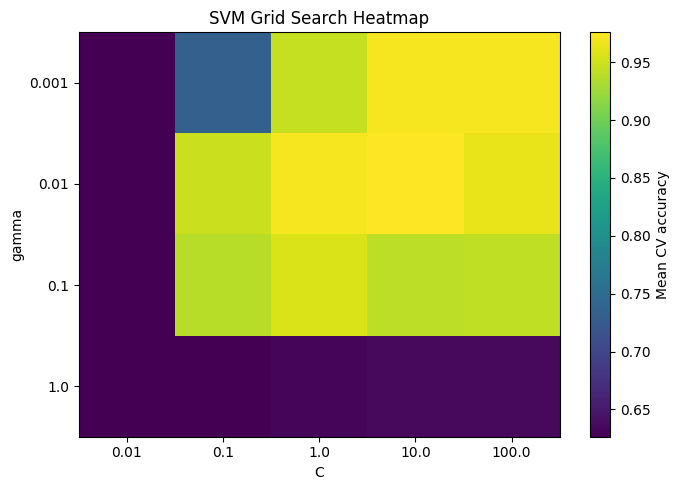

In [52]:
svm_results = pd.DataFrame(svm_grid.cv_results_)

heatmap_data = svm_results.pivot_table(
    values="mean_test_score",
    index="param_svm__gamma",
    columns="param_svm__C"
)

plt.figure(figsize=(7, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Mean CV accuracy")
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.xlabel("C")
plt.ylabel("gamma")
plt.title("SVM Grid Search Heatmap")
plt.tight_layout()
plt.show()

# 6) Select the best tuned model

We will select the model with the highest cross-validation accuracy on the training set.

In [53]:
all_grids = {
    "Decision Tree": tree_grid,
    "SVM": svm_grid,
    "Gradient Boosting": gb_grid,
}

best_model_name = max(all_grids, key=lambda name: all_grids[name].best_score_)
best_grid = all_grids[best_model_name]

print("Best model:", best_model_name)
print("Best CV accuracy:", round(best_grid.best_score_, 4))
print("Best parameters:", best_grid.best_params_)

Best model: SVM
Best CV accuracy: 0.9758
Best parameters: {'svm__C': 10, 'svm__gamma': 0.01}


# 7) Threshold tuning on the training set

A model usually predicts probabilities or scores.

To turn those into class labels, we need a threshold:
- default threshold is usually **0.50**
- but another threshold may be better depending on the goal

Important methodological point:

We will **not** choose the threshold on the test set.

Instead, we will use **out-of-fold predictions on the training set**.
That keeps the test set untouched until the final evaluation.

In [54]:
# Out-of-fold probabilities/scores on the training set
if best_model_name == "SVM":
    oof_scores = cross_val_predict(
        best_grid.best_estimator_,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]
elif best_model_name == "Gradient Boosting":
    oof_scores = cross_val_predict(
        best_grid.best_estimator_,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]
else:
    oof_scores = cross_val_predict(
        best_grid.best_estimator_,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []

for thr in thresholds:
    preds = (oof_scores >= thr).astype(int)
    f1_scores.append(f1_score(y_train, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

print("Chosen threshold:", round(best_threshold, 3))
print("Best training OOF F1:", round(best_f1, 4))

Chosen threshold: 0.42
Best training OOF F1: 0.9826


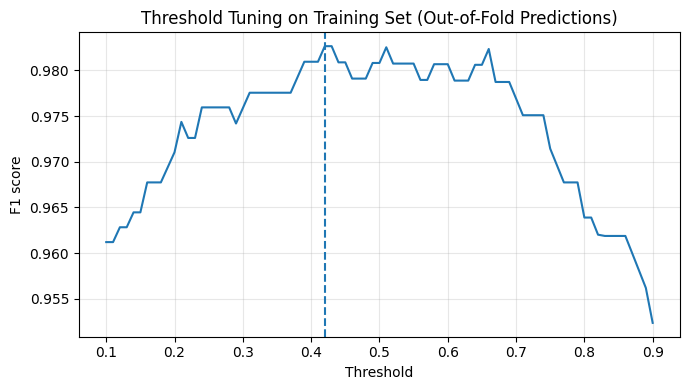

In [55]:
plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("Threshold Tuning on Training Set (Out-of-Fold Predictions)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation
- the threshold is **not always fixed at 0.50**
- different thresholds create different trade-offs
- threshold selection should be done using the **training procedure**, not by peeking at the test set

# 8) Final fit on the full training set

Now that we have:
- chosen the best model
- chosen the threshold using training data only

we can fit the best model on the **full training set**.

In [56]:
final_model = best_grid.best_estimator_
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.01


# 9) Final evaluation on the untouched test set

This is the **first time** we use the test set.

In [57]:
test_scores = final_model.predict_proba(X_test)[:, 1]

y_pred_default = (test_scores >= 0.50).astype(int)
y_pred_tuned = (test_scores >= best_threshold).astype(int)

print("Default threshold (0.50) accuracy:", round(accuracy_score(y_test, y_pred_default), 4))
print("Tuned threshold accuracy:        ", round(accuracy_score(y_test, y_pred_tuned), 4))
print()

print("ROC AUC:", round(roc_auc_score(y_test, test_scores), 4))
print("Average Precision (PR AUC summary):", round(average_precision_score(y_test, test_scores), 4))

Default threshold (0.50) accuracy: 0.9825
Tuned threshold accuracy:         0.9825

ROC AUC: 0.9977
Average Precision (PR AUC summary): 0.9986


## Confusion matrix with tuned threshold

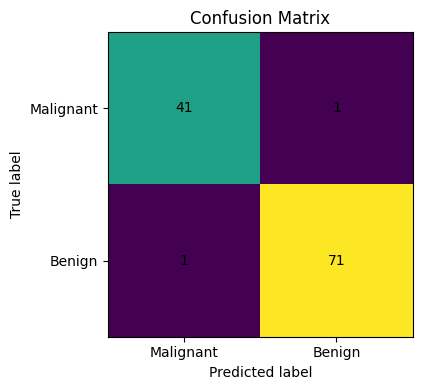

In [58]:
cm = confusion_matrix(y_test, y_pred_tuned)
plot_confusion_matrix_simple(cm, labels=("Malignant", "Benign"))

## Classification report

In [59]:
print(classification_report(y_test, y_pred_tuned, target_names=["malignant", "benign"]))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## ROC curve
ROC is useful when we want to analyze the trade-off between:
- **True Positive Rate (TPR)** (same as recall)  
$
TPR = \frac{TP}{TP + FN}
$

- **False Positive Rate (FPR)**  
$
FPR = \frac{FP}{FP + TN}
$

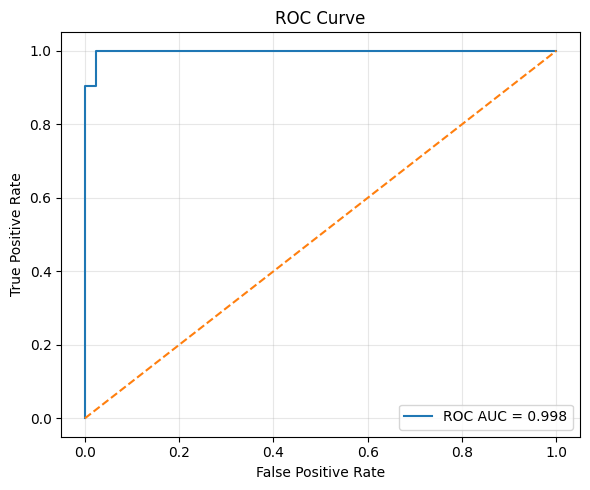

In [60]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_scores)
roc_auc = roc_auc_score(y_test, test_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Precision-Recall curve
PR curves are especially useful when:
- classes are imbalanced
- we care a lot about precision and recall

- **Precision**  
$Precision = \frac{TP}{TP + FP}$

- **Recall**  
$Recall = \frac{TP}{TP + FN}$

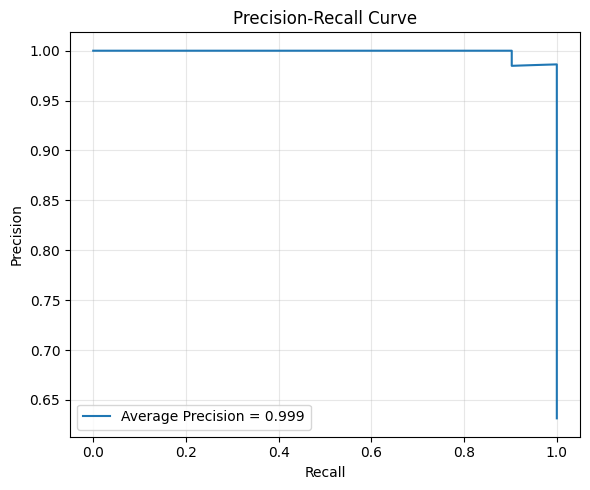

In [61]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, test_scores)
ap = average_precision_score(y_test, test_scores)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"Average Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 10) Take-home questions

1. Why do we split train and test at the beginning?
2. Why is cross-validation done only on the training set?
3. Why can a deeper tree overfit?
4. What do `C` and `gamma` do in SVM?
5. Why is threshold tuning different from model training?
6. Why should we avoid selecting the threshold on the test set?
7. When is ROC more useful? When is PR more useful?

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 

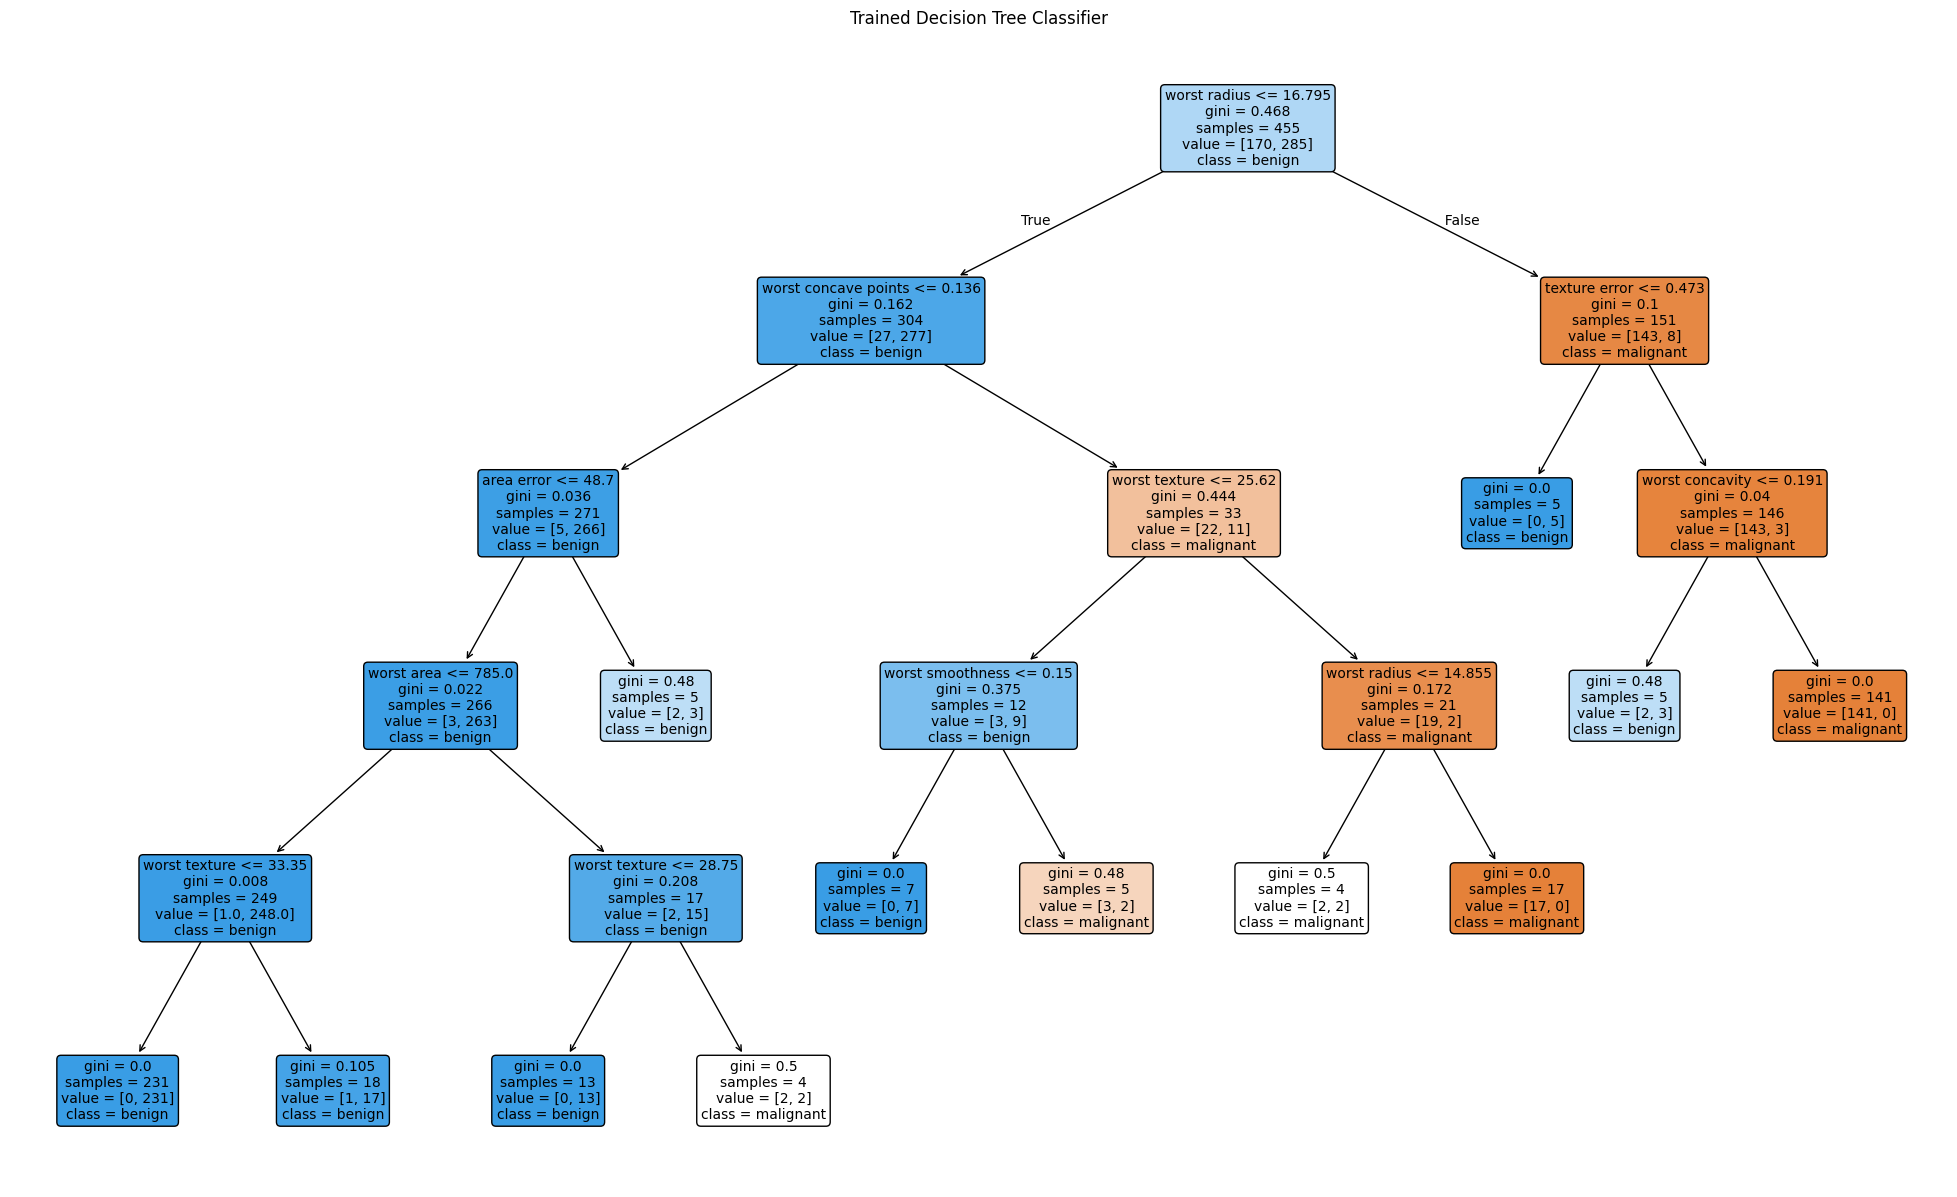

In [62]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Get the best Decision Tree estimator from the grid search
best_tree_model = tree_grid.best_estimator_
print(data.target)
plt.figure(figsize=(25, 15))
plot_tree(best_tree_model, filled=True, feature_names=X.columns, class_names=data.target_names, rounded=True, fontsize=10)
plt.title("Trained Decision Tree Classifier")
plt.show()

**Interpretation**
*   top node = most important split

*   follow conditions down the tree

*   leaf node = final prediction

*   gini measures impurity

*   value shows class counts, i.e. [4,2] -> 4 malignant, 2 benign

### Gini

Gini measures **how mixed the classes are in a node** (impurity).

$Gini = 1 - \sum p_i^2$

where $p_i$ is the proportion of class $i$ in the node.

Interpretation:
- **Gini = 0** → node is **pure** (all samples belong to one class)
- **higher Gini** → classes are **more mixed**
- the tree tries to create splits that **reduce Gini impurity**

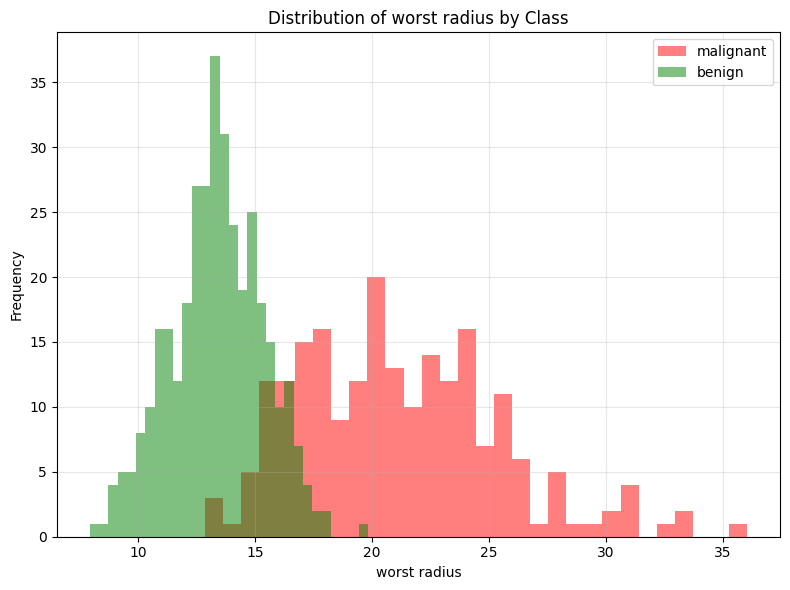

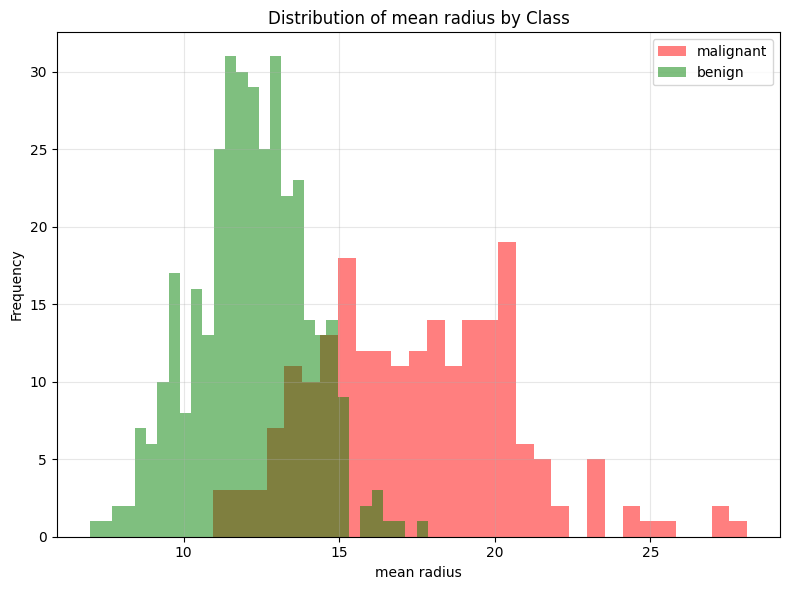

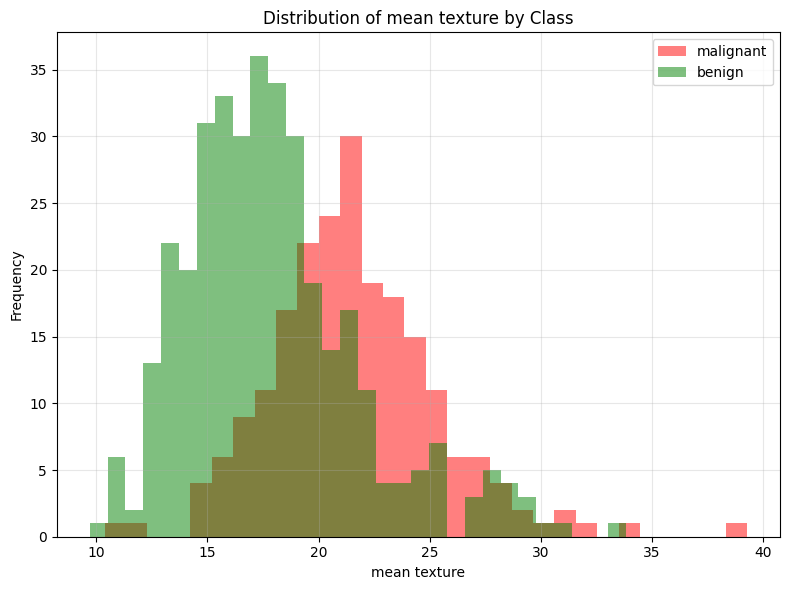

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = pd.concat([X, y], axis=1)

features_to_plot = [
    'worst radius',
    'mean radius',
    'mean texture',
]

for feature in features_to_plot:
    plt.figure(figsize=(8, 6))
    plt.hist(
        df_plot[df_plot['target'] == 0][feature],
        alpha=0.5,
        label=data.target_names[0], # Malignant
        bins=30,
        color='red'
    )
    plt.hist(
        df_plot[df_plot['target'] == 1][feature],
        alpha=0.5,
        label=data.target_names[1], # Benign
        bins=30,
        color='green'
    )
    plt.title(f'Distribution of {feature} by Class')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Agora eu vou tentar

In [97]:
data = pd.read_csv("/Users/josepedro/Downloads/Uni/3ano/2semestre/Aprendizagem Computacional/datasets/archive/diabetes_binary_health_indicators_BRFSS2015.csv")
data1 = pd.read_csv("/Users/josepedro/Downloads/Uni/3ano/2semestre/Aprendizagem Computacional/datasets/diabetes_binary_2k_balanced.csv")


#print(data.columns)

target = "Diabetes_binary"

X = data.drop(columns=target)  # features
y = data[target]                 # label


print("Dataset shape:", X.shape)
print("Class distribution:")
print(y.value_counts().sort_index())
print(data[target].unique())
X.head()

Dataset shape: (253680, 21)
Class distribution:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64
[0. 1.]


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='str')
0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
253675    0.0
253676    1.0
253677    0.0
253678    0.0
253679    1.0
Name: Diabetes_binary, Length: 253680, dtype: float64


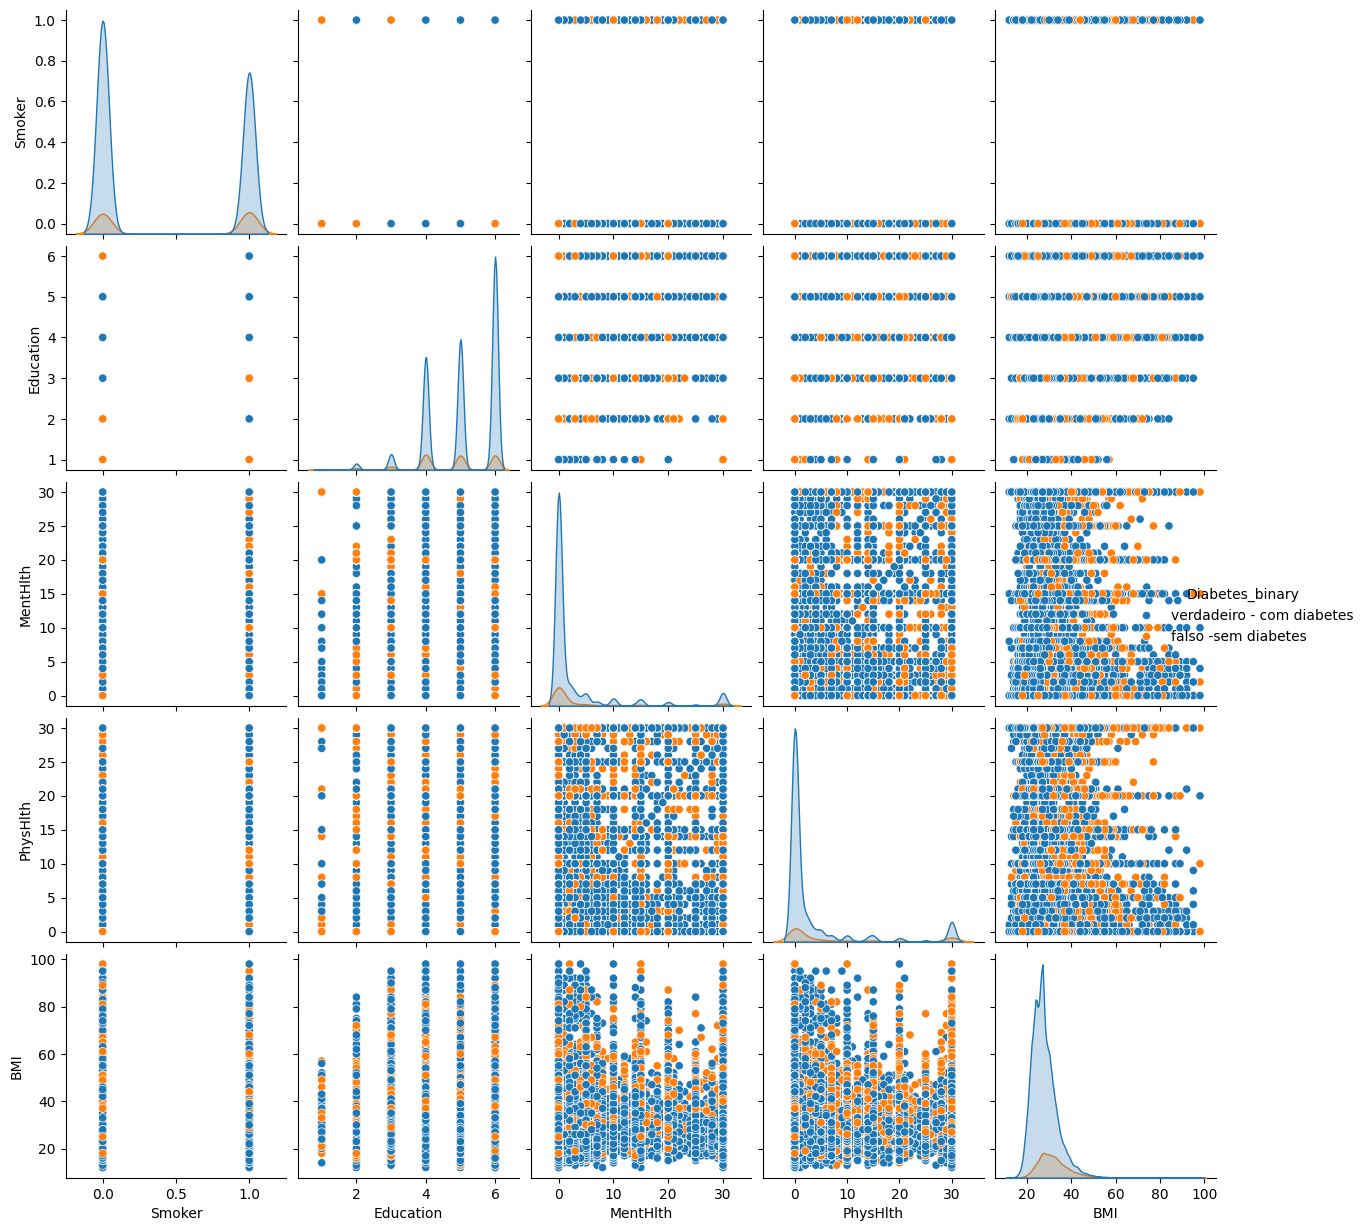

In [98]:
df = X.copy()

print(df.columns)

df[target] = y

print(y)

df = drop_na_rows(df)

g = sns.pairplot(
    df,
    vars=["Smoker","Education","MentHlth","PhysHlth","BMI"],
    hue=target
)

g._legend.set_title(target)
g._legend.texts[0].set_text("verdadeiro - com diabetes")
g._legend.texts[1].set_text("falso -sem diabetes")
plt.show()


In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)



Train shape: (202944, 21)
Test shape:  (50736, 21)


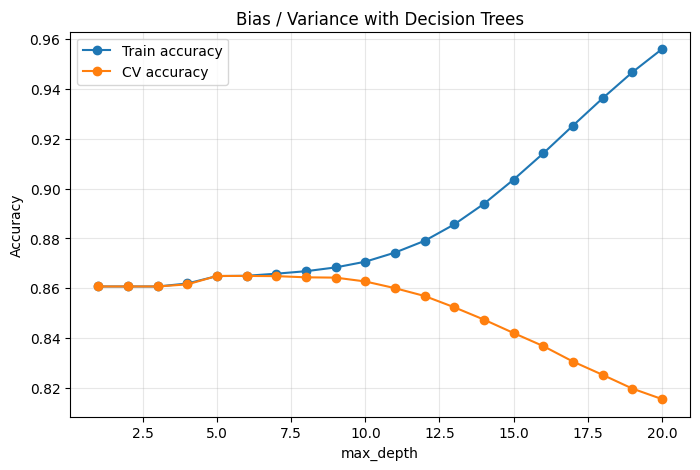

In [100]:
depths = range(1, 21)

train_scores = []
cv_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)

    scores = cross_validate(
        tree,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        return_train_score=True,
        n_jobs=-1
    )

    train_scores.append(scores["train_score"].mean())
    cv_scores.append(scores["test_score"].mean())

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker="o", label="Train accuracy")
plt.plot(depths, cv_scores, marker="o", label="CV accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Bias / Variance with Decision Trees")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [80]:
# print(X)

# print(y)

# X_toy, y_toy = X_train,y_train
# fig, ax = plt.subplots(figsize=(5, 4))
# ax.scatter(X_toy.iloc[:, 0], X_toy.iloc[:, 1], c=y_toy, edgecolor="k", s=35)
# ax.set_title("Toy dataset for SVM intuition")
# ax.set_xlabel("Feature 1")
# ax.set_ylabel("Feature 2")
# plt.tight_layout()
# plt.show()

In [101]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

comparison_rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "roc_auc"],
        n_jobs=-1
    )

    comparison_rows.append({
        "model": name,
        "mean_cv_accuracy": scores["test_accuracy"].mean(),
        "std_cv_accuracy": scores["test_accuracy"].std(),
        "mean_cv_roc_auc": scores["test_roc_auc"].mean(),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("mean_cv_accuracy", ascending=False)
comparison_df

KeyboardInterrupt: 

In [82]:
tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid={
        "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid = GridSearchCV(
    estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    param_grid={
        "svm__C": [0.01, 0.1, 1, 10, 100],
        "svm__gamma": [0.001, 0.01, 0.1, 1],
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid={
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [1, 2, 3],
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)
svm_grid.fit(X_train, y_train)
gb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [1, 2, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and par

In [83]:
all_grids = {
    "Decision Tree": tree_grid,
    "SVM": svm_grid,
    "Gradient Boosting": gb_grid,
}

best_model_name = max(all_grids, key=lambda name: all_grids[name].best_score_)
best_grid = all_grids[best_model_name]

print("Best model:", best_model_name)
print("Best CV accuracy:", round(best_grid.best_score_, 4))
print("Best parameters:", best_grid.best_params_)

Best model: SVM
Best CV accuracy: 0.7463
Best parameters: {'svm__C': 100, 'svm__gamma': 0.001}


In [84]:
# Out-of-fold probabilities/scores on the training set
if best_model_name == "SVM":
    oof_scores = cross_val_predict(
        best_grid.best_estimator_,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]
elif best_model_name == "Gradient Boosting":
    oof_scores = cross_val_predict(
        best_grid.best_estimator_,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]
else:
    oof_scores = cross_val_predict(
        best_grid.best_estimator_,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []

for thr in thresholds:
    preds = (oof_scores >= thr).astype(int)
    f1_scores.append(f1_score(y_train, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

print("Chosen threshold:", round(best_threshold, 3))
print("Best training OOF F1:", round(best_f1, 4))

Chosen threshold: 0.42
Best training OOF F1: 0.7761


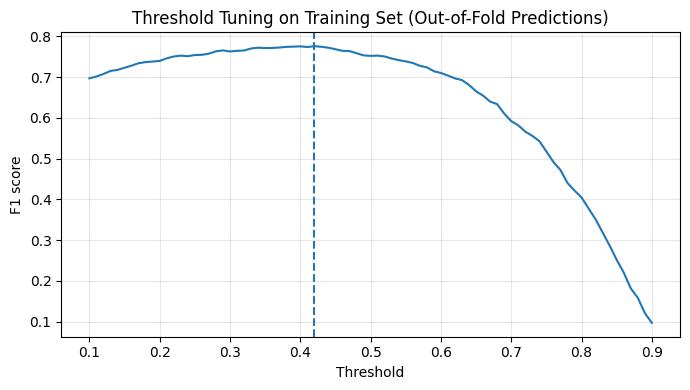

In [85]:
plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("Threshold Tuning on Training Set (Out-of-Fold Predictions)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [86]:
final_model = best_grid.best_estimator_
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.001


In [87]:
test_scores = final_model.predict_proba(X_test)[:, 1]

y_pred_default = (test_scores >= 0.50).astype(int)
y_pred_tuned = (test_scores >= best_threshold).astype(int)

print("Default threshold (0.50) accuracy:", round(accuracy_score(y_test, y_pred_default), 4))
print("Tuned threshold accuracy:        ", round(accuracy_score(y_test, y_pred_tuned), 4))
print()

print("ROC AUC:", round(roc_auc_score(y_test, test_scores), 4))
print("Average Precision (PR AUC summary):", round(average_precision_score(y_test, test_scores), 4))

Default threshold (0.50) accuracy: 0.775
Tuned threshold accuracy:         0.7725

ROC AUC: 0.8467
Average Precision (PR AUC summary): 0.8307


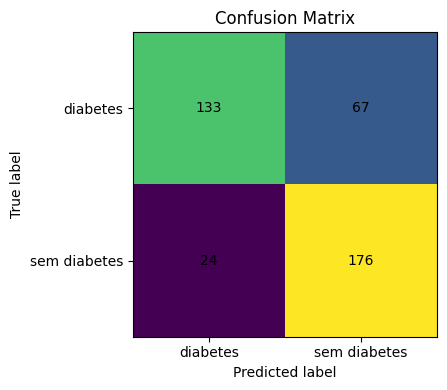

In [88]:
cm = confusion_matrix(y_test, y_pred_tuned)
plot_confusion_matrix_simple(cm, labels=("diabetes", "sem diabetes"))

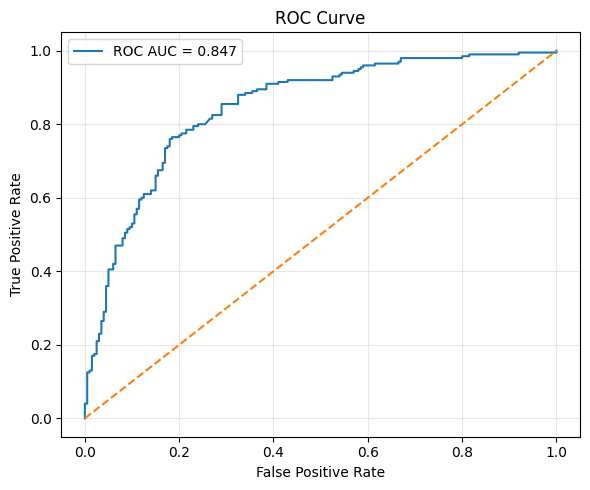

In [89]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_scores)
roc_auc = roc_auc_score(y_test, test_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

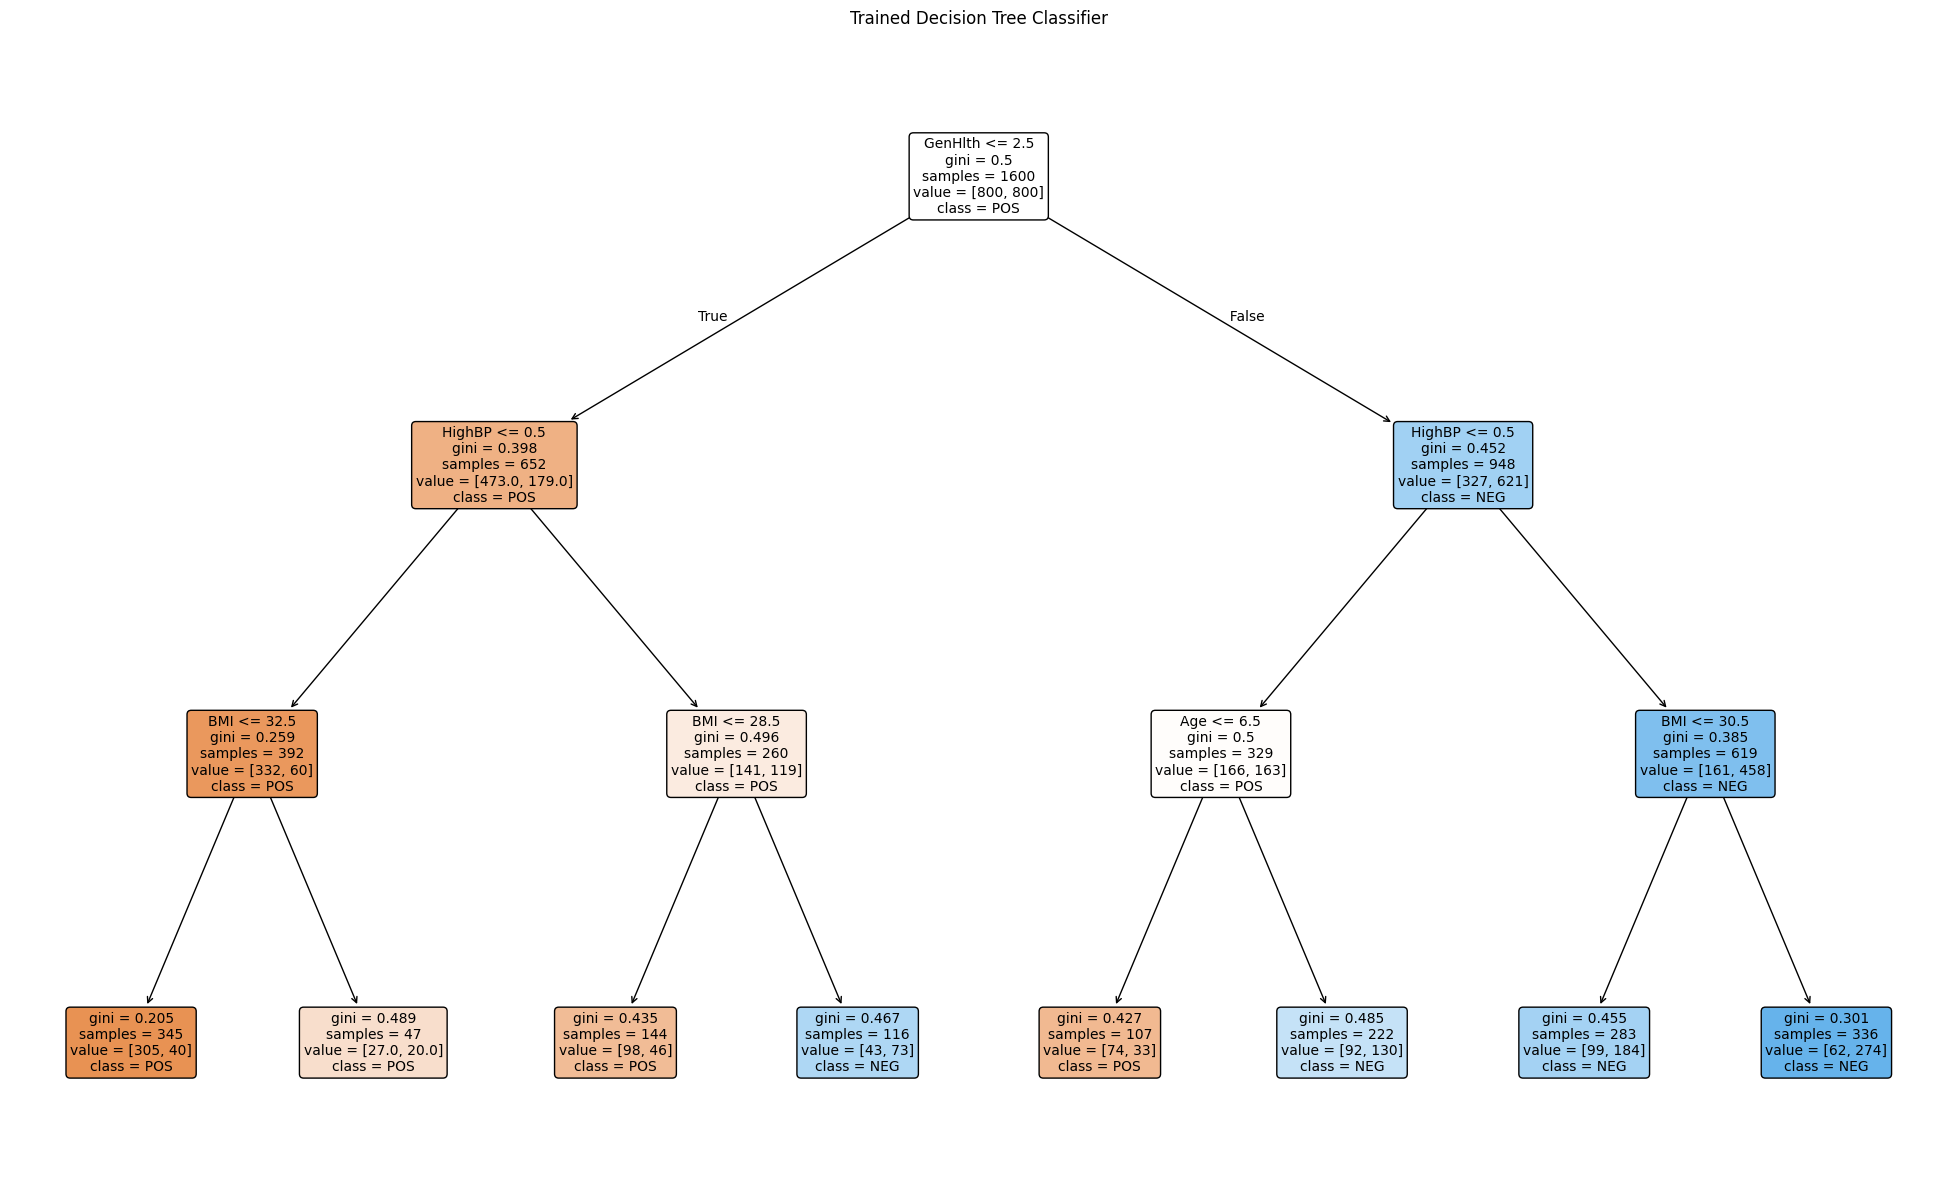

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Get the best Decision Tree estimator from the grid search
best_tree_model = tree_grid.best_estimator_

#
plt.figure(figsize=(25, 15))
plot_tree(best_tree_model, filled=True, feature_names=X.columns, class_names=["NEG","POS"], rounded=True, fontsize=10)
plt.title("Trained Decision Tree Classifier")
plt.show()